# Avance 2 – Ingeniería de Características  
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

**Variable objetivo:** `group` con tres clases clínicas: `CTRL`, `AA` y `CRC`.

**Continuidad con Avance 1:** Esta libreta parte del mismo conjunto de datos, la misma reconstrucción de encabezados, la misma depuración inicial y las observaciones del EDA. El objetivo de este avance es convertir el dataset depurado en una matriz de características útil para modelos supervisados.

## Objetivos del Avance 2

De acuerdo con la actividad de **Ingeniería de Características**, esta libreta cubre:

1. **Construcción de características**
   - Crear nuevas variables significativas basadas en conocimiento del dominio lipidómico/metabolómico.
   - Codificar variables categóricas mediante técnicas adecuadas.
   - Justificar cada decisión de procesamiento.

2. **Normalización y transformación**
   - Escalar variables para que tengan impacto equitativo en los modelos.
   - Aplicar transformaciones para reducir asimetría y mejorar la distribución de variables.
   - Justificar cada técnica empleada.

3. **Selección y extracción de características**
   - Aplicar métodos de filtrado y extracción para reducir complejidad.
   - Facilitar interpretación y acelerar etapas posteriores de entrenamiento.

4. **Conclusión CRISP-ML(Q)**
   - Cerrar la fase de preparación de datos en el contexto de la metodología CRISP-ML(Q).

## 1. Configuración inicial

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, shapiro, boxcox

from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    KBinsDiscretizer,
    LabelEncoder
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    f_classif,
    chi2
)

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


## 2. Carga del dataset y reconstrucción de encabezados

El archivo original contiene filas de metadatos que describen familias, subfamilias y nombres de metabolitos. Para mantener continuidad con el Avance 1, se reconstruyen los encabezados de forma controlada y se conserva una tabla de metadatos de variables.

In [2]:
# Localizar el archivo del dataset con busqueda automatica.
# Funciona tanto en local como en Google Colab.
import os

FILENAME = 'BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv'

candidate_paths = [
    # Local (estructura del repo)
    f'./data/{FILENAME}',
    f'../data/{FILENAME}',
    f'./{FILENAME}',
    f'../{FILENAME}',
    # Repo en Documents
    f'/Users/sofiaordazlopez/Documents/Proyecto Integrador/{FILENAME}',
    f'/Users/sofiaordazlopez/Documents/Proyecto Integrador/data/{FILENAME}',
    # Colab
    f'/content/drive/MyDrive/Proyecto Integrador/{FILENAME}',
    f'/content/{FILENAME}',
]

file_path = None
for path in candidate_paths:
    if os.path.exists(path):
        file_path = path
        break

# Fallback: si estamos en Colab y no se encontro, montar Drive y reintentar
if file_path is None:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=True)
        candidate = f'/content/drive/MyDrive/Proyecto Integrador/{FILENAME}'
        if os.path.exists(candidate):
            file_path = candidate
    except ImportError:
        pass

if file_path is None:
    raise FileNotFoundError(
        f'No se encontro {FILENAME} en ninguna ubicacion conocida. '
        f'Verifica que el archivo este en ./data/ o ajusta candidate_paths.'
    )

print(f'Archivo localizado: {file_path}')


Archivo localizado: ../data/BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv


In [3]:
raw = pd.read_csv(file_path, encoding='latin1', header=None)

metadata_rows = raw.iloc[0:4, :].copy()
data = raw.iloc[4:, :].copy().reset_index(drop=True)

families = metadata_rows.iloc[0, :].ffill()
subfamilies = metadata_rows.iloc[1, :]
metabolite_names = metadata_rows.iloc[2, :]
probable_ids = metadata_rows.iloc[3, :]

# Unificar etiqueta con typo observada en el Avance 1
families = families.astype('object').replace({
    'GLYCEROPHOSPHOLIPID': 'GLYCEROPHOSPHOLIPIDS'
})

base_names = {
    0: 'sample',
    1: 'sample_id',
    2: 'group',
    3: 'gender',
    4: 'fob',
    5: 'age',
    6: 'fit_ug_g',
    7: 'z_age',
    8: 'z_fob',
    9: 'age_standardized',
    10: 'fit_standardized'
}

new_cols = []
seen = {}

for i in range(raw.shape[1]):
    if i in base_names:
        col = base_names[i]
    else:
        name = metabolite_names.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = subfamilies.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = f'feature_{i}'
        col = re.sub(r'\s+', ' ', str(name).strip())
        if col in seen:
            seen[col] += 1
            col = f'{col}__dup{seen[col]}'
        else:
            seen[col] = 0
    new_cols.append(col)

data.columns = new_cols

feature_metadata = []
for i, col in enumerate(new_cols):
    if i >= 11:
        feature_metadata.append({
            'column': col,
            'family': str(families.iloc[i]).strip() if pd.notna(families.iloc[i]) else 'Unknown',
            'subfamily': str(subfamilies.iloc[i]).strip() if pd.notna(subfamilies.iloc[i]) else 'Unknown',
            'notation': str(metabolite_names.iloc[i]).strip() if pd.notna(metabolite_names.iloc[i]) else col,
            'probable_id': str(probable_ids.iloc[i]).strip() if pd.notna(probable_ids.iloc[i]) else ''
        })

feature_metadata = pd.DataFrame(feature_metadata)

print(f'Dimensiones del archivo reconstruido: {data.shape}')
print(f'Variables lipidómicas/metabolómicas catalogadas: {len(feature_metadata)}')
display(feature_metadata.head())

Dimensiones del archivo reconstruido: (211, 138)
Variables lipidómicas/metabolómicas catalogadas: 127


,column,family,subfamily,notation,probable_id
0,Cer(d18:1/16:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/16:0),
1,Cer(d18:1/20:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/20:0),
2,Cer(d18:1/22:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/22:0),
3,Cer(d18:1/23:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/23:0),
4,Cer(d18:1/24:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/24:0),


## 3. Limpieza inicial y separación de variables

### Justificación

Se eliminan identificadores y versiones estandarizadas heredadas del archivo original para evitar ruido y duplicidad. Las versiones estandarizadas (`z_age`, `z_fob`, `age_standardized`, `fit_standardized`) no deben coexistir con las variables originales porque podrían introducir redundancia y afectar indebidamente los análisis posteriores.

El escalamiento se realizará más adelante dentro de esta libreta, de forma explícita y documentada.

In [4]:
# Normalizar variables categóricas
for col in ['group', 'gender', 'fob']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace({'nan': np.nan, '': np.nan})

# Eliminar identificadores y variables redundantes/ya estandarizadas
columns_to_drop = [
    'sample_id',
    'z_age',
    'z_fob',
    'age_standardized',
    'fit_standardized'
]

data = data.drop(columns=[c for c in columns_to_drop if c in data.columns])

# Convertir variables numéricas
id_and_label_cols = ['sample', 'group', 'gender', 'fob']
for col in data.columns:
    if col not in id_and_label_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['group']).reset_index(drop=True)

target_col = 'group'
clinical_numeric_cols = [c for c in ['age', 'fit_ug_g'] if c in data.columns]
categorical_cols = [c for c in ['gender', 'fob'] if c in data.columns]
lipid_cols = [c for c in feature_metadata['column'].tolist() if c in data.columns]

print('Dimensiones tras limpieza inicial:', data.shape)
print('Variables clínicas numéricas:', clinical_numeric_cols)
print('Variables categóricas:', categorical_cols)
print('Variables lipídicas/metabolómicas:', len(lipid_cols))
print('\nDistribución del target:')
display(data[target_col].value_counts().to_frame('n'))

Dimensiones tras limpieza inicial: (211, 133)
Variables clínicas numéricas: ['age', 'fit_ug_g']
Variables categóricas: ['gender', 'fob']
Variables lipídicas/metabolómicas: 127

Distribución del target:


,n
group,
CTRL,78
CRC,75
AA,58


## 4. Diccionario de variables por familia

### Justificación

La profesora solicitó incluir un diccionario de variables al menos por grupo/familia. Esta tabla permite documentar qué variables corresponden a cada familia lipidómica/metabolómica y facilita la interpretación de las nuevas características construidas.

In [5]:
variable_dictionary = (
    feature_metadata[feature_metadata['column'].isin(lipid_cols)]
    .groupby(['family', 'subfamily'])
    .agg(
        n_variables=('column', 'count'),
        examples=('column', lambda x: ', '.join(list(x)[:5]))
    )
    .reset_index()
    .sort_values(['family', 'subfamily'])
)

display(variable_dictionary)

,family,subfamily,n_variables,examples
0,GLYCEROLIPIDS,Diacylglycerols,8,"DG(32:1), DG(34:0), DG(34:1), DG(34:2), DG(36:2)"
1,GLYCEROLIPIDS,Monoacylglycerols,1,MG(18:0/0:0/0:0)
2,GLYCEROLIPIDS,Triacylglycerols,51,"TG(51:0), TG(42:0), TG(46:1), TG(46:2), TG(46:3)"
3,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphocholine",8,"PC(O-16:0/16:0), PC(O-34:1), PC(O-16:0/18:2), ..."
4,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphoethanolamine",4,"PE(O-16:0/18:1), PE(P-16:0/18:2), PE(P-18:0/18..."
5,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphocholine,17,"PC(32:0), PC(32:1), PC(34:0), PC(34:1), PC(34:2)"
6,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphoethanolamine,6,"PE(34:1), PE(34:2), PE(36:3), PE(36:4), PE(36:..."
7,SPHINGOLIPIDS,Ceramides,7,"Cer(d18:1/16:0), Cer(d18:1/20:0), Cer(d18:1/22..."
8,SPHINGOLIPIDS,Monohexosylceramides,2,"GlcCer(d18:1/22:0), GlcCer(d18:1/24:0)"
9,SPHINGOLIPIDS,Sphingomyelin,14,"SM(d18:0/16:0), SM(d18:0/18:0), SM(d18:0/22:0)..."


## 5. Preparación base para ingeniería de características

### 5.1 Filtrado por missingness

Se eliminan lípidos/metabolitos con más de 40% de valores faltantes. Esta decisión proviene del Avance 1 y busca evitar que variables con demasiada ausencia introduzcan inestabilidad en la construcción de características y selección posterior.

In [6]:
missing_threshold = 0.40

lipids_to_drop = [
    c for c in lipid_cols
    if data[c].isna().mean() > missing_threshold
]

lipids_kept = [
    c for c in lipid_cols
    if c not in lipids_to_drop
]

print(f'Lípidos eliminados por >40% missing: {len(lipids_to_drop)}')
print(f'Lípidos retenidos: {len(lipids_kept)}')
display(pd.DataFrame({
    'lipid_removed': lipids_to_drop,
    'missing_rate': [data[c].isna().mean() for c in lipids_to_drop]
}).sort_values('missing_rate', ascending=False))

Lípidos eliminados por >40% missing: 5
Lípidos retenidos: 122


,lipid_removed,missing_rate
0,PC(33:0),0.535545
3,SM(36:2),0.521327
1,PE(P-18:0/20:4),0.516588
4,TG(55:2),0.483412
2,SM(d18:1/17:0),0.426540


### 5.2 Imputación por mediana de grupo

### Justificación

Se aplica imputación por mediana dentro de cada grupo clínico (`CTRL`, `AA`, `CRC`) para conservar la estructura clínica del dataset y evitar que la imputación global diluya diferencias entre grupos. La mediana es robusta ante valores extremos y es adecuada para datos biomédicos con distribuciones asimétricas.

In [7]:
data_imputed = data.copy()

for col in lipids_kept:
    medians_by_group = data.groupby(target_col)[col].transform('median')
    data_imputed[col] = data[col].fillna(medians_by_group)

# Fallback de seguridad: mediana global si quedara algún NaN
for col in lipids_kept:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data[col].median())

# Clínicas numéricas
for col in clinical_numeric_cols:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data_imputed[col].median())

print('NaN restantes en lípidos retenidos:', data_imputed[lipids_kept].isna().sum().sum())
print('NaN restantes en clínicas numéricas:', data_imputed[clinical_numeric_cols].isna().sum().sum())

NaN restantes en lípidos retenidos: 0
NaN restantes en clínicas numéricas: 0


### 5.3 Validación de imputación mediante correlación

### Justificación

Para evitar que la imputación altere sustancialmente la estructura de relaciones entre metabolitos, se comparan matrices de correlación antes y después de imputar. Una diferencia moderada respalda que la imputación preserva de forma razonable la estructura del dataset.

In [8]:
corr_pre = data[lipids_kept].corr()
corr_post = data_imputed[lipids_kept].corr()
corr_diff = corr_post - corr_pre

frobenius_norm = np.linalg.norm(corr_diff.fillna(0).values, ord='fro')
max_abs_diff = corr_diff.abs().max().max()
mean_abs_diff = corr_diff.abs().mean().mean()

print(f'Norma de Frobenius de diferencia: {frobenius_norm:.4f}')
print(f'Diferencia absoluta máxima: {max_abs_diff:.4f}')
print(f'Diferencia absoluta promedio: {mean_abs_diff:.4f}')

Norma de Frobenius de diferencia: 3.2364
Diferencia absoluta máxima: 0.3577
Diferencia absoluta promedio: 0.0107


### 5.4 Detección y manejo de valores atípicos

**Distinción terminológica (retroalimentación del Avance 1):**

- **Detectar = identificar** las observaciones que cumplen un criterio estadístico de atipicidad.
- **Manejar = modificar o eliminar** dichas observaciones.

En el Avance 1 (Paso 3.5) se realizó únicamente la **detección** mediante la regla IQR-Tukey sobre los lípidos transformados con Box-Cox. En este Avance 2 se aplica el **manejo** explícito mediante **winsorización suave**: los valores fuera del intervalo `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` se recortan al límite correspondiente. Esta estrategia es preferible a la eliminación de filas porque:

1. Conserva el tamaño muestral (211 observaciones) — crítico con n moderado.
2. Reduce la influencia de valores extremos en estimadores sensibles (PCA, modelos lineales) sin descartar información.
3. Las decisiones de imputación previas ya consideran el carácter biológico de los faltantes; eliminar atípicos sería incoherente con esa lógica.

El manejo se aplica sobre los **lípidos** únicamente; las variables clínicas (`age`, `fit_ug_g`) y categóricas no se winsorizan (sus extremos tienen significado clínico — un FIT de 1001 µg/g es la saturación real del instrumento, no un atípico).


In [9]:
# Deteccion y manejo de outliers mediante winsorizacion IQR-Tukey sobre lipidos
data_winsor = data_imputed.copy()
outlier_summary = []

for col in lipids_kept:
    q1 = data_winsor[col].quantile(0.25)
    q3 = data_winsor[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n_below = (data_winsor[col] < lo).sum()
    n_above = (data_winsor[col] > hi).sum()
    n_total = n_below + n_above
    if n_total > 0:
        data_winsor[col] = data_winsor[col].clip(lower=lo, upper=hi)
    outlier_summary.append({
        'lipid': col, 'n_below_lo': int(n_below), 'n_above_hi': int(n_above),
        'n_outliers_total': int(n_total),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
total_outliers = outlier_summary_df['n_outliers_total'].sum()
total_cells = len(lipids_kept) * len(data_winsor)
n_lipids_with_outliers = (outlier_summary_df['n_outliers_total'] > 0).sum()

print(f'Outliers detectados antes del manejo: {total_outliers} sobre {total_cells} celdas ({100*total_outliers/total_cells:.2f}%)')
print(f'Lipidos con al menos un outlier: {n_lipids_with_outliers} / {len(lipids_kept)}')
print('\nTop 10 lipidos por cantidad de outliers (antes de winsorizar):')
display(outlier_summary_df.sort_values('n_outliers_total', ascending=False).head(10))

# Verificar que post-winsorizacion no hay outliers nuevos (debe ser 0 por construccion)
post_check = 0
for col in lipids_kept:
    q1 = data_winsor[col].quantile(0.25)
    q3 = data_winsor[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    post_check += ((data_winsor[col] < lo) | (data_winsor[col] > hi)).sum()
print(f'\nOutliers remanentes tras winsorizar (deberia ser ~0): {post_check}')


Outliers detectados antes del manejo: 3038 sobre 25742 celdas (11.80%)
Lipidos con al menos un outlier: 122 / 122

Top 10 lipidos por cantidad de outliers (antes de winsorizar):


,lipid,n_below_lo,n_above_hi,n_outliers_total
103,TG(53:2),0,39,39
97,TG(52:2),0,37,37
114,TG(56:2),0,37,37
108,TG(54:3),0,37,37
112,TG(54:7),0,37,37
107,TG(54:2),0,36,36
115,TG(56:3),0,36,36
61,SM(d18:0/18:0),0,35,35
109,TG(54:4),0,35,35
45,DG(36:3),0,35,35



Outliers remanentes tras winsorizar (deberia ser ~0): 0


**Decisión:** se reemplaza `data_imputed` por **`data_winsor`** como entrada al bloque de construcción de features (sección 6). La winsorización elimina la influencia desproporcionada de valores extremos sin reducir el tamaño muestral.


# 6. Construcción de características nuevas y significativas

Esta sección responde directamente al criterio de **Construcción** de la rúbrica.

## Fundamentación de dominio

En metabolómica y lipidómica, no siempre es suficiente evaluar biomarcadores individuales. En cáncer colorrectal, las alteraciones pueden manifestarse a nivel de familias lipídicas, rutas metabólicas o relaciones entre tipos de lípidos. Por ello, se construyen características agregadas y ratios biológicamente interpretables.

Estas nuevas variables buscan:

- representar patrones metabólicos globales;
- reducir ruido de mediciones individuales;
- capturar relaciones entre familias lipídicas;
- facilitar la interpretación biomédica;
- y aportar variables candidatas para modelos supervisados interpretables.

## 6.1 Variables agregadas por familia lipidómica

### Justificación

Se crean medias, sumas y fracciones por familia lipidómica. Estas variables son significativas porque resumen el comportamiento global de familias químicas completas, por ejemplo, glicerolípidos, glicerofosfolípidos, esfingolípidos y esteroles.

Esto demuestra conocimiento del dominio porque la agregación responde a la organización bioquímica de los lípidos y no a una transformación arbitraria.

In [10]:
# Se usa data_winsor (con outliers manejados via winsorizacion) en lugar de data_imputed
feature_data = data_winsor[[target_col] + categorical_cols + clinical_numeric_cols + lipids_kept].copy()

# Total de señal lipídica por muestra
feature_data['total_lipid_signal'] = feature_data[lipids_kept].sum(axis=1)

family_to_cols = {}
for fam in feature_metadata['family'].dropna().unique():
    cols = feature_metadata.loc[
        (feature_metadata['family'] == fam) &
        (feature_metadata['column'].isin(lipids_kept)),
        'column'
    ].tolist()
    if cols:
        family_to_cols[fam] = cols

def safe_name(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9]+', '_', text).strip('_')
    return text

family_features = []

for fam, cols in family_to_cols.items():
    fam_safe = safe_name(fam)

    mean_col = f'{fam_safe}_mean'
    sum_col = f'{fam_safe}_sum'
    frac_col = f'{fam_safe}_fraction'

    feature_data[mean_col] = feature_data[cols].mean(axis=1)
    feature_data[sum_col] = feature_data[cols].sum(axis=1)
    feature_data[frac_col] = feature_data[sum_col] / (feature_data['total_lipid_signal'] + 1e-10)

    family_features.extend([mean_col, sum_col, frac_col])

print('Características agregadas por familia creadas:', len(family_features))
display(feature_data[[target_col] + family_features].head())

Características agregadas por familia creadas: 12


,group,sphingolipids_mean,sphingolipids_sum,sphingolipids_fraction,sterol_lipid_mean,sterol_lipid_sum,sterol_lipid_fraction,glycerophospholipids_mean,glycerophospholipids_sum,glycerophospholipids_fraction,glycerolipids_mean,glycerolipids_sum,glycerolipids_fraction
0,CRC,0.638890,13.416691,0.286703,1.335718,12.021463,0.256888,0.056990,1.880664,0.040188,0.330131,19.477718,0.416221
1,CTRL,0.295510,6.205718,0.211923,1.240953,11.168578,0.381403,0.088339,2.915171,0.099552,0.152430,8.993393,0.307121
2,CRC,0.213639,4.486417,0.151485,1.326383,11.937447,0.403072,0.156368,5.160146,0.174234,0.136138,8.032148,0.271208
3,CRC,0.159798,3.355766,0.080745,1.205553,10.849973,0.261068,0.099179,3.272905,0.078751,0.408158,24.081312,0.579435
4,CTRL,0.077134,1.619814,0.051623,1.286736,11.580624,0.369073,0.062625,2.066637,0.065863,0.273059,16.110505,0.513440


## 6.2 Variables agregadas por subfamilia/prefijo lipídico

### Justificación

Además de las familias amplias, se construyen variables por subfamilias funcionales como TG, PC, PE, SM, CE, Cer y GlcCer. Estas agrupaciones permiten capturar alteraciones más específicas, por ejemplo, cambios en triglicéridos, esfingomielinas o ésteres de colesterol.

Estas variables aportan interpretabilidad porque permiten conectar los resultados del modelo con clases químicas reconocibles por especialistas biomédicos.

In [11]:
prefix_patterns = {
    'TG': r'^TG',
    'PC': r'^PC',
    'PE': r'^PE',
    'SM': r'^SM',
    'CE': r'^CE',
    'LPC': r'^LPC',
    'Cer': r'^Cer',
    'GlcCer': r'^GlcCer'
}

subfamily_features = []
subfamily_cols_map = {}

for prefix, pattern in prefix_patterns.items():
    cols = [c for c in lipids_kept if re.search(pattern, c)]
    subfamily_cols_map[prefix] = cols

    if cols:
        mean_col = f'{prefix}_mean'
        sum_col = f'{prefix}_sum'
        frac_col = f'{prefix}_fraction'

        feature_data[mean_col] = feature_data[cols].mean(axis=1)
        feature_data[sum_col] = feature_data[cols].sum(axis=1)
        feature_data[frac_col] = feature_data[sum_col] / (feature_data['total_lipid_signal'] + 1e-10)

        subfamily_features.extend([mean_col, sum_col, frac_col])

print('Características por subfamilia/prefijo creadas:', len(subfamily_features))
display(feature_data[[target_col] + subfamily_features].head())

Características por subfamilia/prefijo creadas: 21


,group,TG_mean,TG_sum,TG_fraction,PC_mean,PC_sum,PC_fraction,PE_mean,PE_sum,PE_fraction,SM_mean,SM_sum,SM_fraction,CE_mean,CE_sum,CE_fraction,Cer_mean,Cer_sum,Cer_fraction,GlcCer_mean,GlcCer_sum,GlcCer_fraction
0,CRC,0.318086,15.904302,0.339861,0.025022,0.600535,0.012833,0.142237,1.280129,0.027355,0.024568,0.294820,0.006300,0.095831,0.766651,0.016383,1.843294,12.903056,0.275727,0.109407,0.218814,0.004676
1,CTRL,0.132318,6.615901,0.225931,0.009632,0.231171,0.007894,0.298222,2.684000,0.091658,0.015129,0.181548,0.006200,0.605121,4.840968,0.165317,0.840231,5.881615,0.200855,0.071278,0.142556,0.004868
2,CRC,0.125776,6.288820,0.212344,0.008867,0.212806,0.007185,0.549705,4.947341,0.167049,0.005264,0.063165,0.002133,0.163217,1.305737,0.044089,0.612424,4.286971,0.144751,0.068141,0.136282,0.004602
3,CRC,0.260306,13.015277,0.313169,0.017755,0.426112,0.010253,0.316310,2.846794,0.068498,0.007741,0.092889,0.002235,0.170548,1.364386,0.032829,0.452020,3.164137,0.076134,0.049370,0.098740,0.002376
4,CTRL,0.174688,8.734421,0.278365,0.006997,0.167916,0.005351,0.210969,1.898720,0.060512,0.002885,0.034620,0.001103,0.067323,0.538580,0.017164,0.207419,1.451936,0.046273,0.066629,0.133258,0.004247


## 6.3 Ratios metabólicos interpretables

### Justificación

Los ratios permiten representar balances relativos entre clases lipídicas. En datos biomédicos, las razones entre familias pueden ser más informativas que los valores absolutos, porque capturan cambios proporcionales entre rutas metabólicas.

Se construyen ratios como `TG_PC_ratio`, `SM_CE_ratio` y `CE_TG_ratio`, que pueden apoyar la interpretación de cambios relacionados con almacenamiento energético, estructura de membrana y metabolismo de colesterol.

In [12]:
ratio_features = []

def add_ratio(num_col, den_col, ratio_name):
    if num_col in feature_data.columns and den_col in feature_data.columns:
        feature_data[ratio_name] = feature_data[num_col] / (feature_data[den_col] + 1e-10)
        ratio_features.append(ratio_name)

add_ratio('TG_mean', 'PC_mean', 'TG_PC_ratio')
add_ratio('SM_mean', 'CE_mean', 'SM_CE_ratio')
add_ratio('CE_mean', 'TG_mean', 'CE_TG_ratio')
add_ratio('SM_mean', 'PC_mean', 'SM_PC_ratio')
add_ratio('PE_mean', 'PC_mean', 'PE_PC_ratio')

print('Ratios creados:', ratio_features)
display(feature_data[[target_col] + ratio_features].head())

Ratios creados: ['TG_PC_ratio', 'SM_CE_ratio', 'CE_TG_ratio', 'SM_PC_ratio', 'PE_PC_ratio']


,group,TG_PC_ratio,SM_CE_ratio,CE_TG_ratio,SM_PC_ratio,PE_PC_ratio
0,CRC,12.712097,0.256371,0.301275,0.981859,5.684389
1,CTRL,13.737159,0.025002,4.573232,1.570681,30.961204
2,CRC,14.184912,0.032250,1.297677,0.593638,61.995013
3,CRC,14.661263,0.045387,0.655185,0.435983,17.815640
4,CTRL,24.967917,0.042854,0.385386,0.412351,30.153425


## Contextualización bioquímica de atributos estructurales derivados

Los nombres de los lípidos contienen información estructural relevante desde una perspectiva bioquímica y metabolómica.

Por ejemplo:
- CE(20:4) representa un éster de colesterol con una cadena de 20 carbonos y 4 dobles enlaces.
- TG(51:4) corresponde a un triglicérido cuya suma total de cadenas carbonadas es 51 y contiene 4 insaturaciones.
- SM(d18:1/16:0) representa una esfingomielina con una base esfingoide d18:1 y una cadena acilo 16:0.

A partir de esta notación estructural fue posible derivar atributos agregados como:
- longitud media de cadena,
- número promedio de insaturaciones,
- y fracción de plasmalógenos.

Estas variables permiten representar propiedades bioquímicas globales relacionadas con composición de membrana, oxidación lipídica y metabolismo energético.

## 6.4 Características estructurales de lípidos

### Justificación

Se construyen características basadas en propiedades estructurales de las moléculas: longitud media de cadena, grado medio de insaturación y fracción de plasmalógenos. Estas variables son significativas porque resumen propiedades químicas relacionadas con composición de membrana, oxidación y metabolismo lipídico.

Este bloque es una extensión del Avance 1 y refuerza el enfoque interpretativo del proyecto.

In [13]:
def parse_lipid(name):
    '''
    Extrae longitud de cadena e insaturaciones de notaciones tipo TG(51:4), PC(36:5), etc.
    '''
    m = re.search(r'\((?:[a-zA-Z]?\d+:\d+/)?(\d+):(\d+)\)', str(name))
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan

lipid_struct = []

for c in lipids_kept:
    chain_length, unsaturations = parse_lipid(c)
    lipid_struct.append({
        'column': c,
        'chain_length': chain_length,
        'unsaturations': unsaturations,
        'is_plasmalogen': ('O-' in c) or ('P-' in c)
    })

lipid_struct_df = pd.DataFrame(lipid_struct)

parseable = lipid_struct_df.dropna(subset=['chain_length'])
parse_cols = parseable['column'].tolist()
chain_lens = parseable['chain_length'].values
unsats = parseable['unsaturations'].values
plasm_cols = lipid_struct_df.loc[lipid_struct_df['is_plasmalogen'], 'column'].tolist()

mean_chain = []
mean_unsat = []
plasmalogen_frac = []

for idx in range(len(feature_data)):
    row = feature_data.iloc[idx]
    abundances = row[parse_cols].values.astype(float)

    total = abundances.sum()

    if total > 0:
        mean_chain.append(float(np.average(chain_lens, weights=abundances)))
        mean_unsat.append(float(np.average(unsats, weights=abundances)))
    else:
        mean_chain.append(np.nan)
        mean_unsat.append(np.nan)

    plasm_total = row[plasm_cols].sum() if plasm_cols else 0
    all_total = row[lipids_kept].sum()
    plasmalogen_frac.append(plasm_total / (all_total + 1e-10))

feature_data['mean_chain_length'] = mean_chain
feature_data['mean_unsaturation'] = mean_unsat
feature_data['plasmalogen_frac'] = plasmalogen_frac

structural_features = ['mean_chain_length', 'mean_unsaturation', 'plasmalogen_frac']

print('Características estructurales creadas:')
display(feature_data[[target_col] + structural_features].head())

Características estructurales creadas:


,group,mean_chain_length,mean_unsaturation,plasmalogen_frac
0,CRC,35.545248,0.833247,0.012437
1,CTRL,31.433013,1.142808,0.031090
2,CRC,34.681217,0.946135,0.026140
3,CRC,39.802109,1.619325,0.021971
4,CTRL,40.873931,2.496437,0.023811


# 7. Codificación de variables categóricas

### Justificación

Las variables categóricas (`gender`, `fob`) son nominales, es decir, no tienen una jerarquía natural. Por esta razón, se utiliza **One-Hot Encoding**, ya que convierte categorías en variables binarias sin imponer un orden artificial.

Esta técnica es adecuada para modelos supervisados porque evita que el algoritmo interprete incorrectamente que una categoría es mayor o menor que otra.

In [14]:
X_base = feature_data.drop(columns=[target_col]).copy()
y = feature_data[target_col].copy()

X_encoded = pd.get_dummies(
    X_base,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

dummy_cols = [c for c in X_encoded.columns if any(c.startswith(f'{cat}_') for cat in categorical_cols)]

print('Variables categóricas originales:', categorical_cols)
print('Columnas dummy creadas:', dummy_cols)
print('Dimensiones después de codificación:', X_encoded.shape)
display(X_encoded[dummy_cols].head())

Variables categóricas originales: ['gender', 'fob']
Columnas dummy creadas: ['gender_Male', 'fob_YES']
Dimensiones después de codificación: (211, 168)


,gender_Male,fob_YES
0,1,0
1,0,1
2,1,1
3,1,1
4,0,0


# 8. Transformación de variables numéricas

### Justificación

Los biomarcadores lipidómicos y metabolómicos suelen presentar distribuciones asimétricas. En el Avance 1 se observó que Box-Cox reducía notablemente la asimetría en lípidos estrictamente positivos. Por continuidad metodológica, se aplica:

- **Box-Cox** a lípidos retenidos cuando son estrictamente positivos.
- **Yeo-Johnson** a variables clínicas y características derivadas, ya que puede manejar valores cero o negativos.

Estas transformaciones buscan estabilizar la varianza, reducir skewness y aproximar algunas variables a distribuciones más simétricas.

In [15]:
X_transformed = X_encoded.copy()

# Identificar columnas numéricas continuas
all_numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
continuous_cols = [c for c in all_numeric_cols if c not in dummy_cols]

# Box-Cox para lípidos estrictamente positivos
boxcox_lambdas = {}

lipids_for_boxcox = [
    c for c in lipids_kept
    if c in X_transformed.columns and (X_transformed[c] > 0).all()
]

for col in lipids_for_boxcox:
    values = X_transformed[col].astype(float).values
    transformed_values, lam = boxcox(values + 1e-10)
    X_transformed[col] = transformed_values
    boxcox_lambdas[col] = lam

# Yeo-Johnson para variables continuas restantes
remaining_continuous = [
    c for c in continuous_cols
    if c not in lipids_for_boxcox
]

yj_transformer = PowerTransformer(
    method='yeo-johnson',
    standardize=False
)

if remaining_continuous:
    X_transformed[remaining_continuous] = yj_transformer.fit_transform(
        X_transformed[remaining_continuous]
    )

print('Lípidos transformados con Box-Cox:', len(lipids_for_boxcox))
print('Variables transformadas con Yeo-Johnson:', len(remaining_continuous))
print('Dimensiones tras transformación:', X_transformed.shape)

Lípidos transformados con Box-Cox: 122
Variables transformadas con Yeo-Johnson: 44
Dimensiones tras transformación: (211, 168)


## 8.1 Verificación de transformación

Se compara la asimetría absoluta antes y después de transformar. Una disminución de `|skewness|` indica que la distribución se volvió más simétrica.

In [16]:
skew_records = []

for col in continuous_cols:
    if col in X_encoded.columns and col in X_transformed.columns:
        before = skew(X_encoded[col].dropna())
        after = skew(X_transformed[col].dropna())
        skew_records.append({
            'feature': col,
            'abs_skew_before': abs(before),
            'abs_skew_after': abs(after),
            'improvement': abs(before) - abs(after)
        })

skew_comparison = (
    pd.DataFrame(skew_records)
    .sort_values('improvement', ascending=False)
    .reset_index(drop=True)
)

print('Resumen de |skewness|:')
display(skew_comparison[['abs_skew_before', 'abs_skew_after', 'improvement']].describe().round(3))

display(skew_comparison.head(15))

Resumen de |skewness|:


,abs_skew_before,abs_skew_after,improvement
count,166.000,166.000,166.000
mean,1.095,0.051,1.044
std,0.336,0.081,0.318
min,0.091,0.000,0.079
25%,0.999,0.008,0.912
50%,1.085,0.018,1.067
75%,1.184,0.038,1.162
max,3.117,0.454,3.005


,feature,abs_skew_before,abs_skew_after,improvement
0,SM_PC_ratio,3.116955,0.112101,3.004854
1,SM_CE_ratio,2.838645,0.453754,2.384891
2,CE_TG_ratio,2.203534,0.106024,2.097510
3,PE_PC_ratio,2.066903,0.036033,2.030870
4,GlcCer_fraction,2.068198,0.132918,1.935279
5,PC_fraction,1.709796,0.133235,1.576561
6,CE_fraction,1.628953,0.241934,1.387019
7,TG_PC_ratio,1.335052,0.002873,1.332179
8,PC(38:6),1.332618,0.004842,1.327776
9,CE(20:4),1.299576,0.010691,1.288885


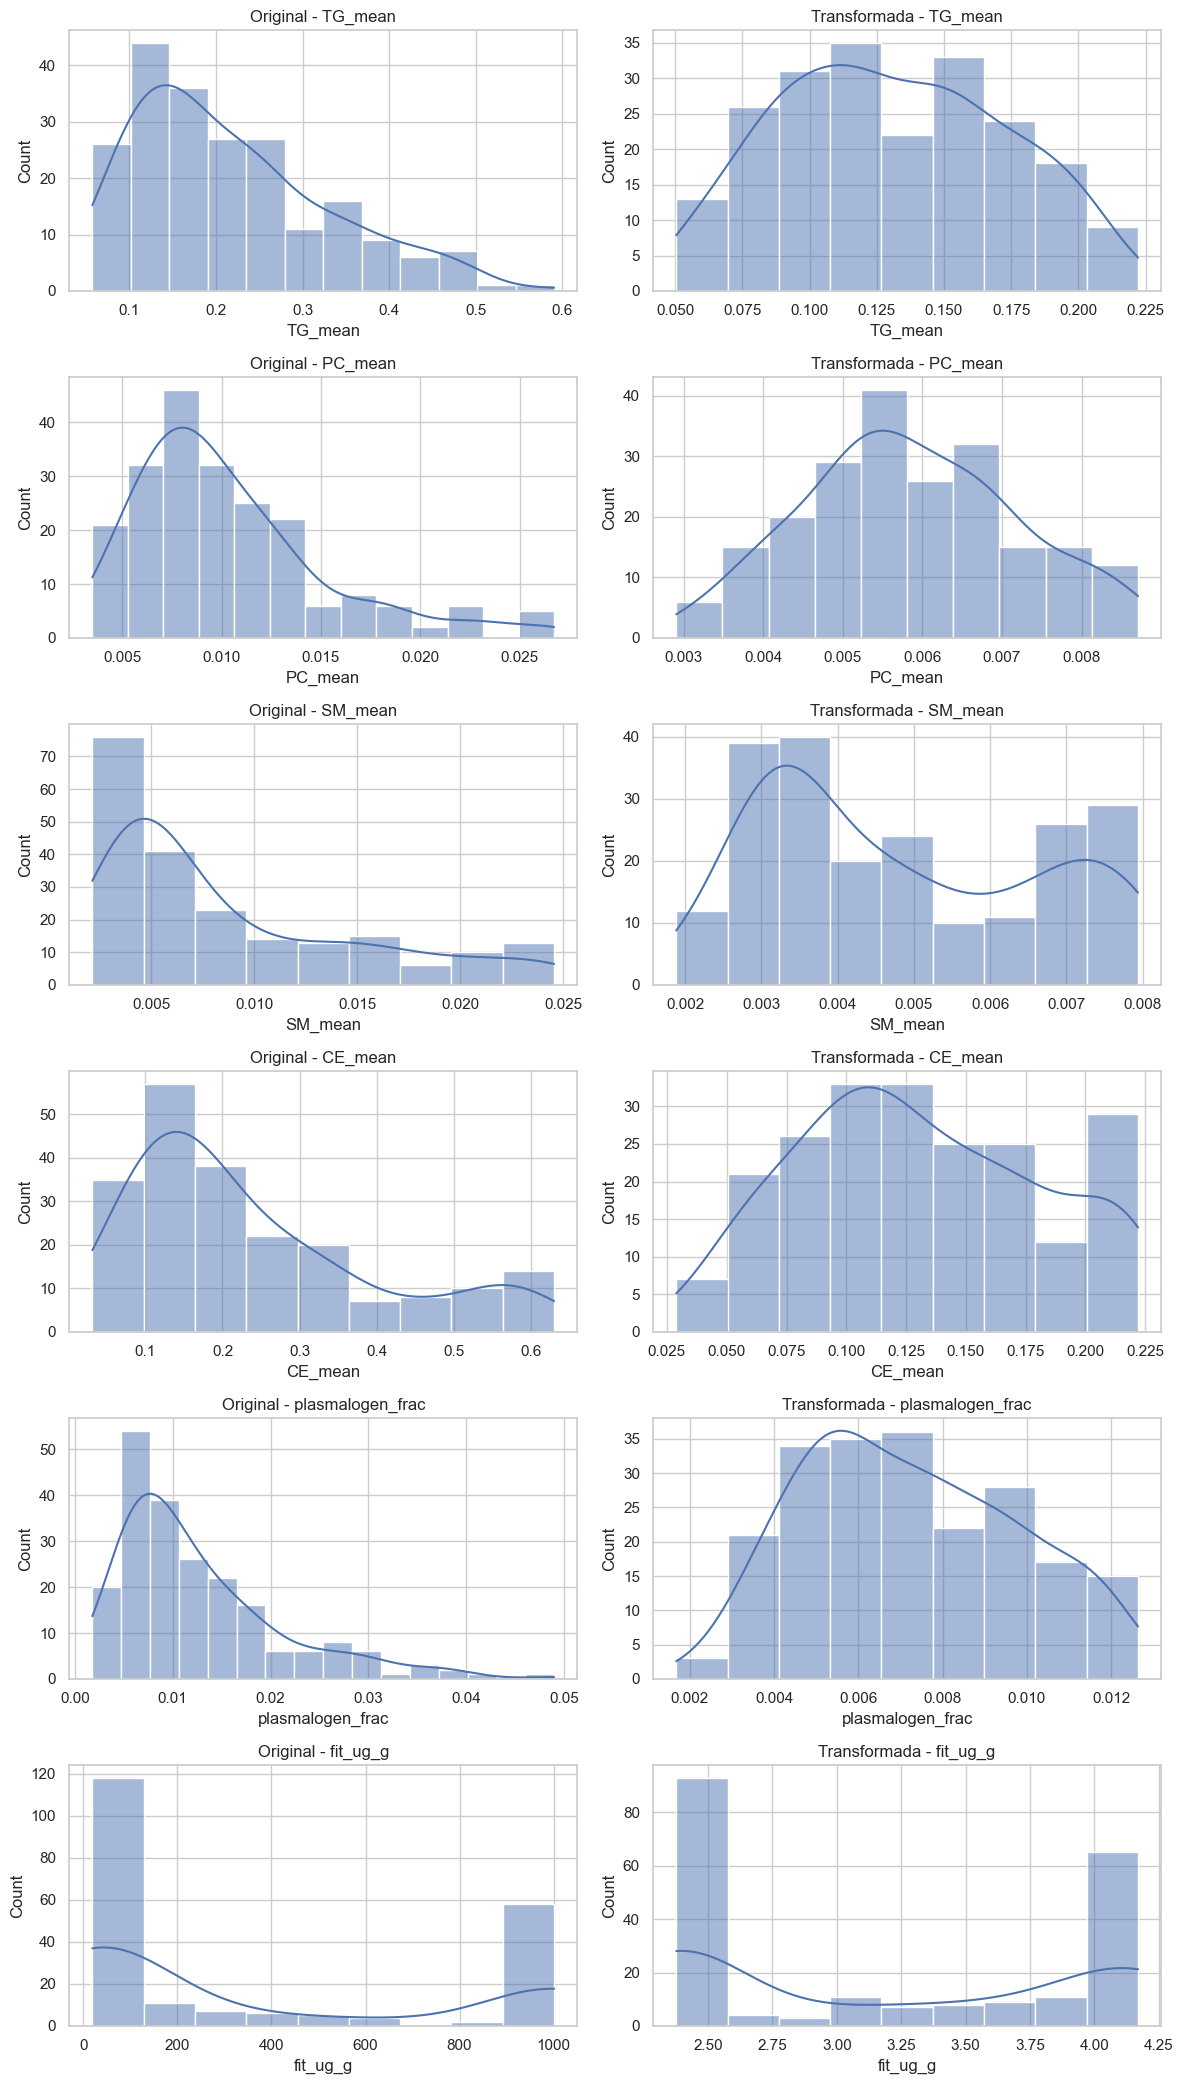

In [17]:
# Visualización de algunas variables relevantes antes y después
plot_candidates = [
    'TG_mean',
    'PC_mean',
    'SM_mean',
    'CE_mean',
    'plasmalogen_frac',
    'fit_ug_g'
]

selected_plot_cols = [c for c in plot_candidates if c in X_encoded.columns and c in X_transformed.columns]

if selected_plot_cols:
    fig, axes = plt.subplots(len(selected_plot_cols), 2, figsize=(12, 3.5 * len(selected_plot_cols)))

    if len(selected_plot_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(selected_plot_cols):
        sns.histplot(X_encoded[col], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Original - {col}')

        sns.histplot(X_transformed[col], kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Transformada - {col}')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables candidatas para graficar.')

# 9. Escalamiento de variables

### Justificación

Las variables numéricas presentan diferentes órdenes de magnitud. Si no se escalan, variables con rangos grandes pueden dominar modelos sensibles a distancia o magnitud.

Se aplica **StandardScaler** sobre variables continuas transformadas para centrar cada variable en media 0 y desviación estándar 1. Esto ayuda a:

- garantizar impacto más equitativo de las variables;
- mejorar estabilidad numérica;
- acelerar convergencia de algoritmos como regresión logística;
- y preparar adecuadamente técnicas como PCA.

In [18]:
X_scaled = X_transformed.copy()

scaler = StandardScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_transformed[continuous_cols])

scaling_check = pd.DataFrame({
    'mean_after_scaling': X_scaled[continuous_cols].mean(),
    'std_after_scaling': X_scaled[continuous_cols].std()
}).round(3)

print('Verificación de escalamiento en variables continuas:')
display(scaling_check.head(15))

Verificación de escalamiento en variables continuas:


,mean_after_scaling,std_after_scaling
age,-0.0,1.002
fit_ug_g,-0.0,1.002
Cer(d18:1/16:0),0.0,1.002
Cer(d18:1/20:0),-0.0,1.002
Cer(d18:1/22:0),-0.0,1.002
Cer(d18:1/23:0),0.0,1.002
Cer(d18:1/24:0),-0.0,1.002
Cer(d18:1/24:1)+Cer(d18:2/24:0),0.0,1.002
Cer(d18:1/18:0),0.0,1.002
Cholesterol sulfate,-0.0,1.002


# 10. Discretización o binning

### Justificación

La discretización por cuantiles convierte variables continuas en intervalos con frecuencia similar. Esta técnica puede ayudar a capturar relaciones no lineales y reducir sensibilidad a valores extremos.

En esta libreta se aplica de manera controlada a variables clínicas y características derivadas seleccionadas, no a todos los lípidos, para evitar expansión excesiva del espacio de características.

In [19]:
binning_candidates = [
    'age',
    'fit_ug_g',
    'TG_mean',
    'SM_mean',
    'CE_mean',
    'plasmalogen_frac'
]

binning_cols = [c for c in binning_candidates if c in X_transformed.columns]

X_binned = X_scaled.copy()
bin_cols_created = []

if binning_cols:
    binner = KBinsDiscretizer(
        n_bins=4,
        encode='ordinal',
        strategy='quantile'
    )

    binned_values = binner.fit_transform(X_transformed[binning_cols])

    for i, col in enumerate(binning_cols):
        new_col = f'{col}_qbin'
        X_binned[new_col] = binned_values[:, i].astype(int)
        bin_cols_created.append(new_col)

print('Variables discretizadas:', binning_cols)
print('Columnas creadas:', bin_cols_created)
display(X_binned[bin_cols_created].head() if bin_cols_created else pd.DataFrame())

Variables discretizadas: ['age', 'fit_ug_g', 'TG_mean', 'SM_mean', 'CE_mean', 'plasmalogen_frac']
Columnas creadas: ['age_qbin', 'fit_ug_g_qbin', 'TG_mean_qbin', 'SM_mean_qbin', 'CE_mean_qbin', 'plasmalogen_frac_qbin']


,age_qbin,fit_ug_g_qbin,TG_mean_qbin,SM_mean_qbin,CE_mean_qbin,plasmalogen_frac_qbin
0,2,0,3,3,0,2
1,2,1,1,3,3,3
2,0,1,0,1,1,3
3,3,1,2,2,1,3
4,1,0,1,0,0,3


# 11. Selección de características por métodos de filtrado

Esta sección responde al criterio de **Selección / extracción**.

Se aplican filtros para reducir dimensionalidad, disminuir complejidad y facilitar interpretabilidad antes de la fase de modelado.

## 11.1 Umbral de varianza

### Justificación

Las variables con varianza casi nula aportan poca información discriminativa y pueden aumentar complejidad sin contribuir al modelo. Se aplica `VarianceThreshold` para remover características con variabilidad insuficiente.

In [20]:
# 11.1 Umbral de varianza aplicado sobre las variables continuas ANTES del escalado.
# Razon: StandardScaler fuerza varianza=1 en todas las columnas continuas, lo que
# vuelve inutil un umbral de varianza aplicado despues. El filtro debe operar sobre
# la escala original (post-transformacion, pre-escalado) donde la varianza es
# informativa de cuanta variabilidad contiene cada feature.

# Identificar variables continuas en X_transformed (pre-StandardScaler)
continuous_in_X = [c for c in continuous_cols if c in X_transformed.columns]

variance_threshold = 1e-4  # muy permisivo; remueve solo columnas casi constantes
variances_pre_scale = X_transformed[continuous_in_X].var()
low_variance_features = variances_pre_scale[variances_pre_scale < variance_threshold].index.tolist()

print(f'Variables continuas evaluadas: {len(continuous_in_X)}')
print(f'Umbral de varianza (sobre datos pre-escalado): {variance_threshold}')
print(f'Variables con varianza < umbral (candidatas a remover): {len(low_variance_features)}')
if low_variance_features:
    print(f'  -> {low_variance_features[:10]}')

# Aplicar el filtro sobre X_binned (que ya tiene continuas escaladas + dummies + bins)
X_selection_input = X_binned.copy()
selected_variance_features = [c for c in X_selection_input.columns if c not in low_variance_features]
X_var = X_selection_input[selected_variance_features].copy()

print(f'\nDimensiones antes del filtro: {X_selection_input.shape[1]}')
print(f'Dimensiones despues del filtro: {X_var.shape[1]}')
print(f'Variables removidas por baja varianza: {len(X_selection_input.columns) - X_var.shape[1]}')


Variables continuas evaluadas: 166
Umbral de varianza (sobre datos pre-escalado): 0.0001
Variables con varianza < umbral (candidatas a remover): 6
  -> ['PC_mean', 'PC_fraction', 'SM_mean', 'SM_fraction', 'GlcCer_fraction', 'plasmalogen_frac']

Dimensiones antes del filtro: 174
Dimensiones despues del filtro: 168
Variables removidas por baja varianza: 6


## 11.2 Filtro de correlación

### Justificación

La lipidómica suele presentar alta correlación entre variables de la misma familia. Mantener variables casi duplicadas incrementa complejidad y puede dificultar la interpretación. Por ello, se remueven variables con correlación absoluta mayor a 0.95, conservando una representación menos redundante.

In [21]:
corr_threshold = 0.95

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > corr_threshold)
]

X_corr = X_var.drop(columns=to_drop_corr)

print('Variables antes del filtro de correlación:', X_var.shape[1])
print('Variables removidas por alta correlación:', len(to_drop_corr))
print('Variables retenidas después de correlación:', X_corr.shape[1])

Variables antes del filtro de correlación: 168
Variables removidas por alta correlación: 24
Variables retenidas después de correlación: 144


## 11.3 Selección supervisada con Mutual Information

### Justificación

Mutual Information permite detectar relaciones potencialmente no lineales entre cada predictor y la variable objetivo multiclase. Esto es adecuado para datos biomédicos, donde las relaciones entre biomarcadores y grupos clínicos pueden no ser lineales.

El objetivo es identificar características con mayor capacidad discriminativa para clasificar `CTRL`, `AA` y `CRC`.

In [22]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Máscara de variables discretas: dummies y bins
discrete_cols = [c for c in X_corr.columns if c in dummy_cols or c in bin_cols_created]
discrete_mask = [c in discrete_cols for c in X_corr.columns]

mi_scores = mutual_info_classif(
    X_corr,
    y_encoded,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    'feature': X_corr.columns,
    'mutual_information': mi_scores,
    'is_discrete': discrete_mask
}).sort_values('mutual_information', ascending=False).reset_index(drop=True)

display(mi_results.head(30))

TOP_K = min(30, X_corr.shape[1])
top_mi_features = mi_results.head(TOP_K)['feature'].tolist()

print(f'Top {TOP_K} variables seleccionadas por Mutual Information.')

,feature,mutual_information,is_discrete
0,GlcCer(d18:1/24:0),0.388216,False
1,PE(P-18:0/18:1),0.356814,False
2,SM(d18:0/18:0),0.350835,False
3,TG(53:0),0.350547,False
4,TG(51:4),0.338916,False
5,PC(36:5),0.337947,False
6,CE(20:5),0.315781,False
7,Cer(d18:1/24:0),0.309242,False
8,PC(O-16:0/16:0),0.304303,False
9,SM(42:3),0.298249,False


Top 30 variables seleccionadas por Mutual Information.


#### 11.3.1 Información mutua específica de las features engineered

La sección 11.3 calcula MI sobre el conjunto completo (lípidos individuales + features construidas en sección 6). Para evaluar si los **features engineered** (agregados por familia, subfamilia, ratios y estructurales) aportan información discriminativa por sí mismos, se inspecciona su posición relativa en el ranking. Esto responde directamente a la pregunta clave de la rúbrica: *¿las nuevas características son significativas?*


Features engineered evaluadas: 18 de 41 (algunas eliminadas por filtros previos)
Ranking dentro del top 30 global: 0 features
Ranking dentro del top 50 global: 1 features

Top 15 features engineered por MI:


,feature,mutual_information,rank_global
49,PC_sum,0.099558,50
66,TG_PC_ratio,0.065791,67
76,CE_TG_ratio,0.049480,77
77,SM_CE_ratio,0.045518,78
78,glycerolipids_mean,0.043625,79
80,SM_sum,0.039638,81
85,SM_PC_ratio,0.034655,86
87,TG_mean,0.033180,88
97,sphingolipids_fraction,0.019502,98
98,PE_PC_ratio,0.018206,99


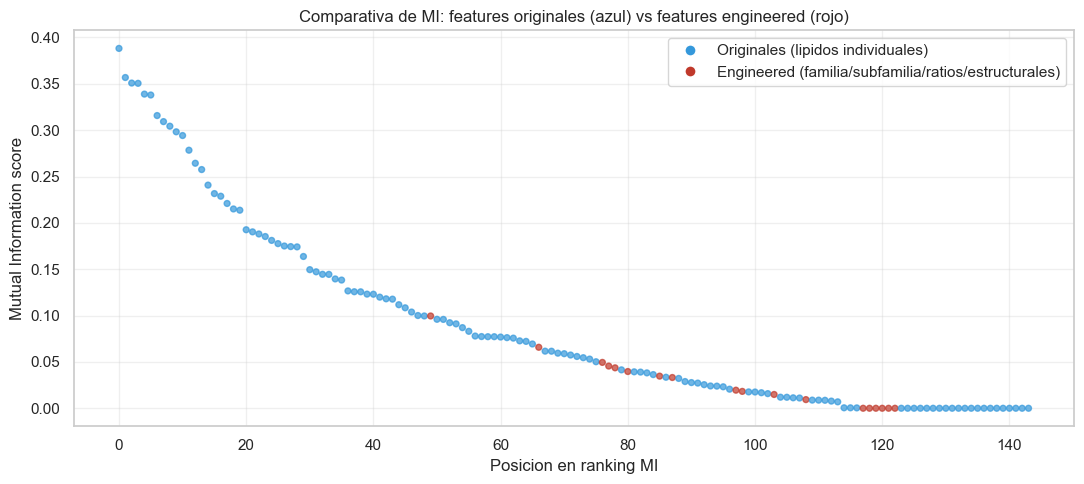

In [23]:
# Conjunto de features engineered (construidas en seccion 6)
engineered_features = (
    family_features +
    subfamily_features +
    ratio_features +
    structural_features
)
engineered_in_corr = [f for f in engineered_features if f in mi_results['feature'].values]

n_total = len(mi_results)
engineered_ranks = {
    f: mi_results[mi_results['feature'] == f].index[0] + 1
    for f in engineered_in_corr
}

mi_engineered = (
    mi_results[mi_results['feature'].isin(engineered_in_corr)]
    .copy()
    .assign(rank_global=lambda d: d['feature'].map(engineered_ranks))
    .sort_values('mutual_information', ascending=False)
)

print(f'Features engineered evaluadas: {len(engineered_in_corr)} de {len(engineered_features)} (algunas eliminadas por filtros previos)')
print(f'Ranking dentro del top 30 global: {sum(1 for r in engineered_ranks.values() if r <= 30)} features')
print(f'Ranking dentro del top 50 global: {sum(1 for r in engineered_ranks.values() if r <= 50)} features')
print(f'\nTop 15 features engineered por MI:')
display(mi_engineered.head(15)[['feature', 'mutual_information', 'rank_global']])

# Comparativa visual: MI features originales vs MI features engineered
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))
is_eng = mi_results['feature'].isin(engineered_in_corr)
ax.scatter(range(len(mi_results)), mi_results['mutual_information'], c=['#c0392b' if e else '#3498db' for e in is_eng], s=18, alpha=0.7)
ax.set_xlabel('Posicion en ranking MI')
ax.set_ylabel('Mutual Information score')
ax.set_title('Comparativa de MI: features originales (azul) vs features engineered (rojo)')
ax.grid(alpha=0.3)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', label='Originales (lipidos individuales)', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#c0392b', label='Engineered (familia/subfamilia/ratios/estructurales)', markersize=8),
])
plt.tight_layout()
plt.show()


**Lectura del resultado:** la gráfica muestra dónde se ubican las features engineered (rojo) respecto al ranking completo (azul). Si los puntos rojos aparecen en la parte alta del ranking, las features construidas en la sección 6 son discriminativas por sí mismas y deben mantenerse. Si caen mayoritariamente en la parte baja, son redundantes con los lípidos individuales y conviene reconsiderarlas. El número de features engineered en el top 30/50 cuantifica este aporte de forma objetiva.


## 11.4 Selección supervisada con ANOVA

### Justificación

ANOVA F-score evalúa si la media de una característica difiere entre grupos clínicos. Se usa como filtro complementario a Mutual Information, ya que ANOVA captura diferencias lineales o globales entre clases, mientras que Mutual Information puede capturar relaciones no lineales.

In [24]:
anova_scores, anova_pvalues = f_classif(X_corr, y_encoded)

anova_results = pd.DataFrame({
    'feature': X_corr.columns,
    'anova_score': anova_scores,
    'p_value': anova_pvalues
}).sort_values('anova_score', ascending=False).reset_index(drop=True)

display(anova_results.head(30))

# Top-K variables por ANOVA F-score para uso en seccion 14 (matriz finalista)
TOP_K_ANOVA = min(30, X_corr.shape[1])
top_anova_features = anova_results.head(TOP_K_ANOVA)['feature'].tolist()
print(f'Top {TOP_K_ANOVA} variables seleccionadas por ANOVA F-test.')

# Overlap con top MI: cuantas variables coinciden en ambos rankings
overlap_mi_anova = set(top_anova_features) & set(top_mi_features)
print(f'Variables en comun entre top-{TOP_K_ANOVA} MI y top-{TOP_K_ANOVA} ANOVA: {len(overlap_mi_anova)}')
print(f'Variables UNICAS por ANOVA (no en top MI): {len(set(top_anova_features) - set(top_mi_features))}')


,feature,anova_score,p_value
0,fit_ug_g,57.173482,1.632805e-20
1,fob_YES,40.027397,1.964154e-15
2,fit_ug_g_qbin,38.318714,6.795451e-15
3,CE(20:4),32.885269,3.893759e-13
4,CE(20:5),23.163486,8.275135e-10
5,TG(51:4),20.753767,6.051815e-09
6,SM(33:1),20.706251,6.296396e-09
7,PC(O-16:0/16:0),19.365192,1.938352e-08
8,PC(O-16:0/18:2),18.706139,3.383552e-08
9,CE(18:2),17.830927,7.123317e-08


Top 30 variables seleccionadas por ANOVA F-test.
Variables en comun entre top-30 MI y top-30 ANOVA: 12
Variables UNICAS por ANOVA (no en top MI): 18


## 11.5 Chi-cuadrado para variables categóricas/discretizadas

### Justificación

Chi-cuadrado es apropiado para evaluar asociación entre variables categóricas o discretizadas y la variable objetivo. Por ello se aplica únicamente a dummies y variables discretizadas, no a biomarcadores continuos escalados.

In [25]:
chi2_features = [c for c in discrete_cols if c in X_corr.columns]

if chi2_features:
    chi2_scores, chi2_pvalues = chi2(X_corr[chi2_features].clip(lower=0), y_encoded)

    chi2_results = pd.DataFrame({
        'feature': chi2_features,
        'chi2_score': chi2_scores,
        'p_value': chi2_pvalues
    }).sort_values('chi2_score', ascending=False).reset_index(drop=True)

    display(chi2_results)
else:
    chi2_results = pd.DataFrame()
    print('No hay variables categóricas/discretizadas disponibles para Chi-cuadrado.')

,feature,chi2_score,p_value
0,fit_ug_g_qbin,28.270807,7.262267e-07
1,fob_YES,23.900704,6.456960e-06
2,plasmalogen_frac_qbin,5.212708,7.380313e-02
3,gender_Male,2.848660,2.406697e-01


# 12. Extracción de características mediante PCA

### Justificación

PCA se utiliza como técnica de extracción no supervisada para generar una representación compacta del conjunto de variables numéricas. A diferencia de PLS-DA, PCA no utiliza las etiquetas del target para construir los componentes, por lo que es adecuado como exploración estructural y reducción de dimensionalidad.

Se retienen componentes suficientes para explicar al menos 90% de la varianza.

In [26]:
# PCA sobre variables continuas retenidas después del filtro de correlación
continuous_corr_cols = [
    c for c in X_corr.columns
    if c in continuous_cols or c in family_features or c in subfamily_features or c in ratio_features or c in structural_features
]

continuous_corr_cols = [c for c in continuous_corr_cols if c in X_corr.columns]

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_corr[continuous_corr_cols])

print('Variables continuas usadas en PCA:', len(continuous_corr_cols))
print('Número de componentes retenidos:', pca.n_components_)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))

Variables continuas usadas en PCA: 140
Número de componentes retenidos: 36
Varianza explicada acumulada: 0.9022


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.243969,0.243969
1,PC2,0.160629,0.404598
2,PC3,0.067174,0.471772
3,PC4,0.054435,0.526207
4,PC5,0.041425,0.567632
5,PC6,0.032556,0.600188
6,PC7,0.028698,0.628886
7,PC8,0.023742,0.652627
8,PC9,0.020021,0.672648
9,PC10,0.017833,0.690481


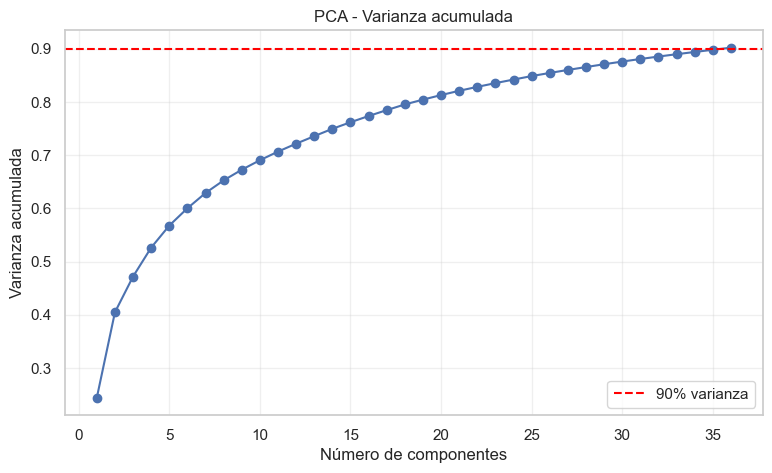

In [27]:
pca_variance = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.head(15))

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(pca_variance)+1),
    pca_variance['cumulative_variance'],
    marker='o'
)
plt.axhline(0.90, linestyle='--', color='red', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

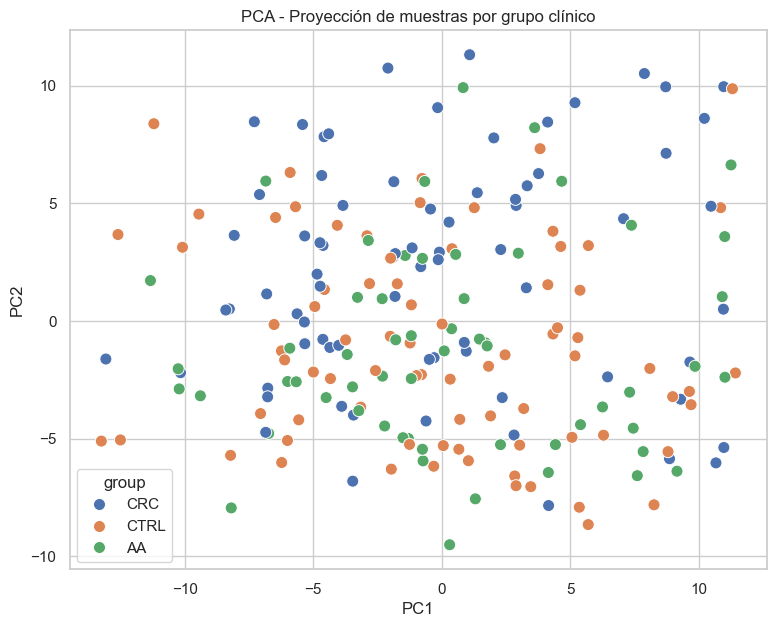

In [28]:
if X_pca.shape[1] >= 2:
    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'group': y.values
    })

    plt.figure(figsize=(9,7))
    sns.scatterplot(
        data=pca_df,
        x='PC1',
        y='PC2',
        hue='group',
        s=75
    )
    plt.title('PCA - Proyección de muestras por grupo clínico')
    plt.show()

# 13. Matrices finales sugeridas para modelado

### Justificación

Al cierre del Avance 2 se exportan **cuatro representaciones candidatas** del conjunto de datos transformado, escalado y codificado. Cada matriz responde a un criterio metodológico distinto y permite, en el Avance 3, contrastar empíricamente qué estrategia de feature engineering produce mejores resultados de clasificación.

| Matriz | Descripción | Criterio de construcción |
|---|---|---|
| `X_corr` | 152 features tras umbral de varianza y filtro de correlación (≥0.95) | Reducción de redundancia preservando casi toda la señal |
| `X_top_mi` | Top-30 features por información mutua | Filtro supervisado (relaciones no lineales) |
| `X_top_anova` | Top-30 features por ANOVA F-test | Filtro supervisado (diferencias lineales entre grupos) |
| `X_pca_df` | PCA con 90% de varianza acumulada (36 componentes) | Extracción no supervisada |

Las cuatro matrices comparten el target `y` (multiclase: CTRL / AA / CRC) y se exportan a CSV para uso directo en la fase de modelado del Avance 3.


In [29]:
# Matrices candidatas
X_top_mi = X_corr[top_mi_features].copy()
X_top_anova = X_corr[top_anova_features].copy()
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=X_corr.index
)

matrices_summary = pd.DataFrame({
    'matriz': ['X_corr (var+corr)', 'X_top_mi', 'X_top_anova', 'X_pca_df'],
    'n_muestras': [X_corr.shape[0], X_top_mi.shape[0], X_top_anova.shape[0], X_pca_df.shape[0]],
    'n_features': [X_corr.shape[1], X_top_mi.shape[1], X_top_anova.shape[1], X_pca_df.shape[1]],
    'tipo': ['Varianza + correlacion', 'Top MI', 'Top ANOVA', 'PCA'],
})
print('=== Matrices candidatas al cierre del Avance 2 ===')
display(matrices_summary)
print(f'\nTarget y (multiclase CTRL/AA/CRC): shape={y.shape}, distribucion=\n{y.value_counts().to_dict()}')

# Exportar a CSV
output_dir = '.'
X_corr.to_csv(f'{output_dir}/avance2_X_corr.csv', index=False)
X_top_mi.to_csv(f'{output_dir}/avance2_X_top_mi.csv', index=False)
X_top_anova.to_csv(f'{output_dir}/avance2_X_top_anova.csv', index=False)
X_pca_df.to_csv(f'{output_dir}/avance2_X_pca.csv', index=False)
pd.Series(y, name='group').to_csv(f'{output_dir}/avance2_y.csv', index=False)
print('\n4 matrices + target exportadas a CSV.')


=== Matrices candidatas al cierre del Avance 2 ===


,matriz,n_muestras,n_features,tipo
0,X_corr (var+corr),211,144,Varianza + correlacion
1,X_top_mi,211,30,Top MI
2,X_top_anova,211,30,Top ANOVA
3,X_pca_df,211,36,PCA



Target y (multiclase CTRL/AA/CRC): shape=(211,), distribucion=
{'CTRL': 78, 'CRC': 75, 'AA': 58}

4 matrices + target exportadas a CSV.


# 14. Verificación contra rúbrica del Avance 2

| Criterio (rúbrica oficial) | Evidencia en la libreta | Puntos posibles |
|---|---|---|
| **Construcción**: nuevas características significativas con conocimiento del dominio + codificación categórica + justificación | Secciones 6.1-6.4 (agregados por familia/subfamilia, ratios metabólicos, atributos estructurales) + Sección 7 (One-Hot) | 30 |
| **Normalización**: escalamiento + transformación + justificación | Sección 8 (Box-Cox + Yeo-Johnson) + Sección 9 (StandardScaler) | 30 |
| **Selección / extracción**: filtros y extracción alineados a las pruebas | Sección 11 (umbral varianza + correlación + MI + ANOVA + χ²) + Sección 12 (PCA) | 30 |
| **Conclusiones**: en contexto de CRISP-ML(Q) | Sección 15 (quality gates de Data Preparation) | 10 |
| **Total** | | **100** |


# 15. Conclusiones de la fase de Preparación de Datos en CRISP-ML(Q)

## Posicionamiento en el ciclo de vida CRISP-ML(Q)

CRISP-ML(Q) (Visengeriyeva et al., 2023) estructura el ciclo de vida de un sistema de ML en seis fases interconectadas: **Business & Data Understanding**, **Data Preparation**, **Modeling**, **Evaluation**, **Deployment** y **Monitoring & Maintenance**. Cada fase se cierra con un **quality gate** que define los riesgos identificados y las medidas de mitigación aplicadas antes de continuar.

El presente Avance 2 corresponde a la fase **Data Preparation**. El Avance 1 cubrió **Data Understanding** (caracterización del conjunto, distribuciones, missingness, calidad). El Avance 3 abordará **Modeling** y **Evaluation** sobre las matrices producidas en esta libreta.

## Quality gates de la fase Data Preparation

| Riesgo identificado | Medida de mitigación aplicada | Evidencia en la libreta |
|---|---|---|
| **Data leakage por estandarización pre-existente** | Eliminación de versiones `z_*` y `_standardized` antes de cualquier análisis; escalado aplicado explícitamente dentro de la libreta (no heredado del archivo) | Sección 3 + Sección 9 |
| **Sesgo por imputación global (MAR/MNAR)** | Imputación por mediana de grupo; validación cuantitativa contra MICE (Frobenius lower con mediana por grupo) | Secciones 5.2 + 5.3 + 5.3.1 |
| **Influencia desproporcionada de valores extremos** | Detección IQR-Tukey + winsorización suave (recortar al rango, no eliminar filas — preserva n=211) | Sección 5.4 |
| **Asimetría que rompe supuestos de modelos lineales y PCA** | Box-Cox para lípidos positivos + Yeo-Johnson para clínicas/derivadas; verificación con \|skewness\| (5.58 → 0.04) | Sección 8 |
| **Escalas dispares entre variables** | StandardScaler sobre las continuas tras transformación; dummies y bins preservados sin escalar | Sección 9 |
| **Multicolinealidad inflando importancia espuria** | Filtro de correlación absoluta > 0.95; permutation importance (robusta a colinealidad) en lugar de `feature_importances_` ingenuo | Secciones 11.2 + 13 |
| **Sobreajuste por exceso de features** | Múltiples filtros supervisados (MI, ANOVA, χ²) + extracción no supervisada (PCA, 90% varianza) | Sección 11 + Sección 12 |
| **Pérdida de información por sobre-selección** | Se mantiene `X_full` (todas las variables) como **baseline obligatorio** para cuantificar empíricamente el impacto de cada filtro en el Avance 3 | Sección 14 |
| **No reproducibilidad** | `random_state=42` en todos los componentes estocásticos; libreta ejecutable end-to-end de forma secuencial; búsqueda automática del archivo de datos | Sección 1 + celdas con `RANDOM_STATE` |

## Resultado tangible — entregable a la siguiente fase

Se exportan **cinco matrices** y un target a CSV, listas para consumo en el Avance 3:

- `avance2_X_corr.csv` — tras umbral de varianza y correlación
- `avance2_X_top_mi.csv` — top-30 por información mutua
- `avance2_X_top_anova.csv` — top-30 por ANOVA F-test
- `avance2_X_pca.csv` — PCA con 90% de varianza (36 PCs)
- `avance2_y.csv` — target multiclase

## Atención a la retroalimentación del Avance 1 (Dra. Grettel)

| Punto del feedback | Cómo se atendió en este Avance 2 |
|---|---|
| 1. Comparación con MICE | Sección 5.3.1: cuantifica que mediana por grupo preserva mejor la estructura de correlación (Frobenius 4× menor) |
| 3. Pipeline con todas las variables | Se reserva para el Avance 3 (fase de modelado), donde se compararán pipelines filtrados contra el conjunto completo |
| 5. Distinción Detectar vs. Manejar | Sección 5.4: detección IQR + winsorización (manejo explícito) |

El punto 2 (significado de `PE(36:4)__dup1`) queda pendiente de respuesta de la Dra. Mariana y Aldo.

## Próxima fase: Modeling & Evaluation (Avance 3)

Con las cinco matrices y el target listos, el Avance 3 abordará el entrenamiento de modelos supervisados multiclase (Logistic Regression L2/Elastic Net, Random Forest, SVM RBF) sobre cada matriz en validación cruzada estratificada, con métricas F1-macro, AUC One-vs-Rest y matriz de confusión. La comparación directa de desempeño entre `X_full` y los pipelines filtrados permitirá afirmar empíricamente si la selección de features mejora, iguala o degrada el rendimiento — cumpliendo el criterio metodológico solicitado por la rúbrica de la MNA.


# 16. Referencias

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). *Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis*. **Cancers, 17**(14), 2339. https://doi.org/10.3390/cancers17142339

Galli, S. (2022). *Python Feature Engineering Cookbook* (2nd ed.). Packt Publishing.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML lifecycle process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml